##BAGIAN 1: Instalasi & Import Library

In [ ]:
# --- PART 1: ENVIRONMENT SETUP ---
import pandas as pd
import numpy as np
import urllib.parse
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math
import os

# Import Transformers with Safe Fallback
try:
    from transformers import BertModel, BertTokenizer
    print("✅ Transformers library loaded successfully.")
except ImportError:
    print("🚀 Transformers not found. Installing...")
    !pip install transformers
    from transformers import BertModel, BertTokenizer

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Hardware Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device in use: {DEVICE}")

# ⚠️ UPDATE THIS PATH TO MATCH YOUR FILE IN GOOGLE COLAB ⚠️
FILENAME = '/content/datasets_before_preprocessing_upgraded.csv'
MODEL_NAME = "jackaduma/SecBERT"

✅ Transformers library loaded successfully.
✅ Device in use: cuda


##BAGIAN 2: Load Data & Deep Decoding

In [ ]:
# --- PART 2: LOAD & PREPROCESSING ---
import pandas as pd
import urllib.parse
from sklearn.model_selection import train_test_split

def load_and_clean_data(filename):
    print(f"📂 Loading dataset: {filename}")
    try:
        df = pd.read_csv(filename)
    except FileNotFoundError:
        print("⚠️ File not found! Please ensure the CSV has been uploaded.")
        return None

    # Deep Decoding Function (Recursive)
    def deep_decode(text):
        text = str(text)
        try:
            # Stage 1 Decode
            d1 = urllib.parse.unquote_plus(text)
            # Stage 2 Decode (for double encoding)
            d2 = urllib.parse.unquote_plus(d1)
            return d2.lower() # Lowercase normalization
        except:
            return text.lower()

    print("🧹 Cleaning text (Deep Decoding)...")
    df['clean_text'] = df['DATA (PLAINTEXT)'].apply(deep_decode)

    # === PREVIEW: BEFORE & AFTER ===
    print("\n👀 PREVIEW: Before vs After Deep Decoding")
    print("-" * 80)
    # Check for encoded characters to show the effect of decoding
    sample_df = df[df['DATA (PLAINTEXT)'].str.contains('%', na=False)].head(5)
    if sample_df.empty:
        sample_df = df.head(5)

    for index, row in sample_df.iterrows():
        print(f"BEFORE : {row['DATA (PLAINTEXT)']}")
        print(f"AFTER  : {row['clean_text']}")
        print("-" * 80)
    # ================================================

    return df

# Execute Load
# (Ensure FILENAME is defined in Part 1)
df_full = load_and_clean_data(FILENAME)

# Split Data (Stratified so attack samples are evenly distributed)
if df_full is not None:
    # Create temporary labels for data splitting (not for final training)
    def get_temp_label(row):
        text = str(row['clean_text']).upper()
        keywords = ["UNION", "SELECT", "SCRIPT", "ALERT", "OR 1=1", "../"]
        if any(k in text for k in keywords):
            return 1
        return 0

    df_full['stratify_label'] = df_full.apply(get_temp_label, axis=1)

    train_df, test_df = train_test_split(
        df_full,
        test_size=0.3, # 30% Testing
        random_state=42,
        stratify=df_full['stratify_label']
    )

    print(f"\n✅ Training Data : {len(train_df)} rows")
    print(f"✅ Testing Data  : {len(test_df)} rows")

📂 Loading dataset: /content/datasets_before_preprocessing_upgraded.csv
🧹 Cleaning text (Deep Decoding)...

👀 PREVIEW: Before vs After Deep Decoding
--------------------------------------------------------------------------------
BEFORE : username=admin&password=Wv0%VIzo*Q&login=submit
AFTER  : username=admin&password=wv0%vizo*q&login=submit
--------------------------------------------------------------------------------
BEFORE : username=%27+OR+%271%27%3D%271&password=123&login=submit
AFTER  : username=' or '1'='1&password=123&login=submit
--------------------------------------------------------------------------------
BEFORE : username=admin&password=t6PNrA%J&I&login=submit
AFTER  : username=admin&password=t6pnra%j&i&login=submit
--------------------------------------------------------------------------------
BEFORE : username=admin&password=eY@c!BV#%3&login=submit
AFTER  : username=admin&password=ey@c!bv#%3&login=submit
----------------------------------------------------------------

In [ ]:
# --- PART 2: LOAD & PREPROCESSING ---

def load_and_clean_data(filename):
    print(f"📂 Loading dataset: {filename}")
    try:
        df = pd.read_csv(filename)
    except FileNotFoundError:
        print("⚠️ File not found! Please ensure you have uploaded the CSV.")
        return None

    # Deep Decoding Function (Recursive)
    def deep_decode(text):
        text = str(text)
        try:
            # Stage 1 Decode
            d1 = urllib.parse.unquote_plus(text)
            # Stage 2 Decode (to handle double encoding)
            d2 = urllib.parse.unquote_plus(d1)
            return d2.lower() # Lowercase normalization
        except:
            return text.lower()

    print("🧹 Cleaning text (Deep Decoding)...")
    df['clean_text'] = df['DATA (PLAINTEXT)'].apply(deep_decode)
    return df

# Execute Load
df_full = load_and_clean_data(FILENAME)

# Split Data (Stratified so attack samples are distributed evenly)
if df_full is not None:
    # Create temporary labels only for data splitting (not for training)
    def get_temp_label(row):
        text = str(row['clean_text']).upper()
        # Common attack signatures for stratification
        keywords = ["UNION", "SELECT", "SCRIPT", "ALERT", "OR 1=1", "../"]
        if any(k in text for k in keywords):
            return 1
        return 0

    df_full['stratify_label'] = df_full.apply(get_temp_label, axis=1)

    train_df, test_df = train_test_split(
        df_full,
        test_size=0.3, # 30% Testing
        random_state=42,
        stratify=df_full['stratify_label']
    )

    print(f"✅ Training Data : {len(train_df)} rows")
    print(f"✅ Testing Data  : {len(test_df)} rows")

📂 Loading dataset: /content/datasets_before_preprocessing_upgraded.csv
🧹 Cleaning text (Deep Decoding)...
✅ Training Data : 3512 rows
✅ Testing Data  : 1506 rows


##BAGIAN 3: Feature Engineering

In [ ]:
# --- PART 3: MANUAL FEATURE EXTRACTION (SNIPER) ---

# Shannon Entropy Function (Measure of string randomness/chaos)
def calculate_entropy(text):
    text = str(text)
    if not text: return 0
    counts = Counter(text)
    # Calculate probability of each character
    freqs = [cnt/len(text) for cnt in counts.values()]
    # Formula: H(x) = -sum(p * log2(p))
    return -sum(p * math.log2(p) for p in freqs)

def process_manual_features(df, scaler=None, is_training=True):
    df = df.copy()
    mode = 'TRAINING' if is_training else 'TESTING'
    print(f"⚙️ Processing statistical features for {mode}...")

    # 1. Time-based Features (Night Owl Activity)
    df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'], dayfirst=True, errors='coerce')
    df['hour'] = df['TIMESTAMP'].dt.hour
    # Flag activity between 10 PM and 5 AM
    df['is_night'] = df['hour'].apply(lambda x: 1 if (x >= 22 or x <= 5) else 0)

    # 2. IP Frequency (Log Scale)
    ip_counts = df['SOURCE IP'].value_counts().to_dict()
    df['ip_freq_log'] = np.log1p(df['SOURCE IP'].map(ip_counts))

    # 3. Risk Character Count (Indicator for SQLi/XSS)
    def count_risk_chars(text):
        # Common characters/keywords used in web exploits
        risk_chars = ["'", '"', "--", "#", "<", ">", ";", "union", "select", "script"]
        return sum(str(text).count(c) for c in risk_chars)

    df['risk_char_count'] = df['clean_text'].apply(count_risk_chars)

    # 4. Shannon Entropy (Indicator for Obfuscation/Encrypted Payloads)
    df['entropy'] = df['clean_text'].apply(calculate_entropy)

    # 5. Port Behavior Risk (Suspicious Port + High Frequency)
    if 'DEST PORT' in df.columns:
        # Flag non-standard web ports
        is_bad_port = df['DEST PORT'].apply(lambda x: 1 if x not in [80, 443] else 0)
        df['port_risk'] = is_bad_port * (df['ip_freq_log'] > 2.0).astype(int)
    else:
        df['port_risk'] = 0

    # 6. Foreign Context Risk (Cross-border Activity)
    if 'SOURCE_COUNTRY' in df.columns and 'DEST_COUNTRY' in df.columns:
        is_foreign = (df['SOURCE_COUNTRY'] != df['DEST_COUNTRY']).astype(int)
        # Risk is amplified if cross-border traffic carries a payload
        df['foreign_risk'] = is_foreign * df['risk_char_count']
    else:
        df['foreign_risk'] = 0

    # Normalization (Scaling)
    cols = ['is_night', 'ip_freq_log', 'risk_char_count', 'entropy', 'port_risk', 'foreign_risk']

    if is_training:
        scaler = StandardScaler()
        features = scaler.fit_transform(df[cols])
        return features, scaler, df
    else:
        features = scaler.transform(df[cols])
        return features, None, df

# Data Processing Execution
manual_train, scaler_model, train_df_processed = process_manual_features(train_df, is_training=True)
manual_test, _, test_df_processed = process_manual_features(test_df, scaler=scaler_model, is_training=False)

⚙️ Processing statistical features for TRAINING...
⚙️ Processing statistical features for TESTING...


##BAGIAN 4: Training (SimCLR)

🔄 Starting SimCLR Training on 3512 samples...
⏳ Target: 10 Epochs


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/336M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: jackaduma/SecBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Epoch 1/10 - Loss: 0.0552
   Epoch 2/10 - Loss: 0.0271
   Epoch 3/10 - Loss: 0.0261
   Epoch 4/10 - Loss: 0.0275
   Epoch 5/10 - Loss: 0.0236
   Epoch 6/10 - Loss: 0.0288
   Epoch 7/10 - Loss: 0.0263
   Epoch 8/10 - Loss: 0.0218
   Epoch 9/10 - Loss: 0.0240
   Epoch 10/10 - Loss: 0.0259
💾 Saving model to ./secbert_simclr_model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

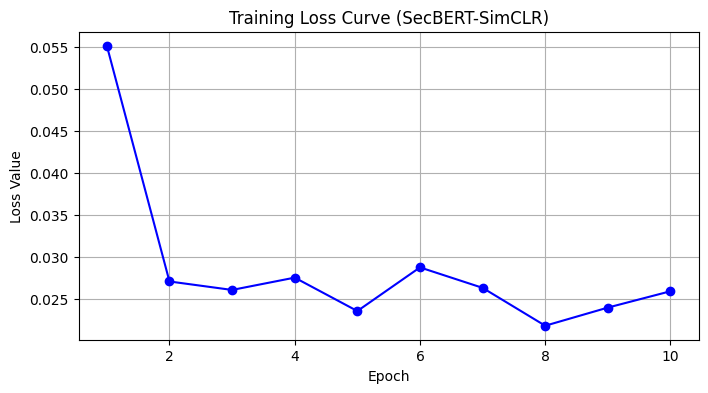

In [ ]:
# --- PART 4: SimCLR TRAINING ---

class ContrastiveDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=64):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        inputs = self.tokenizer(
            str(self.texts[item]),
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten()
        }

def train_simclr_visual(texts, model_name, epochs=10, save_path="./secbert_simclr_model"):
    print(f"🔄 Starting SimCLR Training on {len(texts)} samples...")
    print(f"⏳ Target: {epochs} Epochs")

    # Load Model & Tokenizer
    try:
        tokenizer = BertTokenizer.from_pretrained(model_name)
        model = BertModel.from_pretrained(model_name).to(DEVICE)
    except:
        from transformers import AutoTokenizer, AutoModel
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModel.from_pretrained(model_name).to(DEVICE)

    model.train()
    dataset = ContrastiveDataset(texts, tokenizer)
    loader = DataLoader(dataset, batch_size=16, shuffle=True)
    optimizer = AdamW(model.parameters(), lr=1e-5)

    loss_history = []

    for epoch in range(epochs):
        total_loss = 0
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            optimizer.zero_grad()

            # Forward Pass (Dual View)
            out_a = model(input_ids, attention_mask=mask)
            out_b = model(input_ids, attention_mask=mask)

            # Extract [CLS] token embeddings
            emb_a = out_a.last_hidden_state[:, 0, :] if hasattr(out_a, 'last_hidden_state') else out_a[0][:, 0, :]
            emb_b = out_b.last_hidden_state[:, 0, :] if hasattr(out_b, 'last_hidden_state') else out_b[0][:, 0, :]

            # Calculate Contrastive Loss (Cosine Similarity)
            # Temperature set to 0.05
            cos_sim = F.cosine_similarity(emb_a.unsqueeze(1), emb_b.unsqueeze(0), dim=2) / 0.05
            labels = torch.arange(cos_sim.size(0)).long().to(DEVICE)
            loss = F.cross_entropy(cos_sim, labels)

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        loss_history.append(avg_loss)
        print(f"   Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

    # Save Model
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    print(f"💾 Saving model to {save_path}...")
    model.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)

    # Plot Training Loss
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, epochs+1), loss_history, marker='o', color='b')
    plt.title('Training Loss Curve (SecBERT-SimCLR)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss Value')
    plt.grid(True)
    plt.show()

    return model, tokenizer

# Run Training (10 EPOCHS)
trained_model, trained_tokenizer = train_simclr_visual(
    train_df_processed['clean_text'].tolist(),
    MODEL_NAME,
    epochs=10
)

##BAGIAN 5: Hybrid Fusion & Deteksi Anomali

In [ ]:
# --- PART 5: HYBRID FUSION & ISOLATION FOREST ---

def get_embeddings(model, tokenizer, texts):
    model.eval()
    all_emb = []
    batch_size = 32
    print("🚀 Extracting Vector Embeddings...")

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=64).to(DEVICE)
        with torch.no_grad():
            out = model(**inputs)
            # Use the [CLS] token as the representative vector for the sequence
            emb = out.last_hidden_state[:, 0, :] if hasattr(out, 'last_hidden_state') else out[0][:, 0, :]
            all_emb.append(emb.cpu().numpy())

    return np.vstack(all_emb)

# 1. Language Feature Extraction
bert_train = get_embeddings(trained_model, trained_tokenizer, train_df_processed['clean_text'].tolist())
bert_test = get_embeddings(trained_model, trained_tokenizer, test_df_processed['clean_text'].tolist())

# 2. Dimensionality Reduction (PCA) to balance SecBERT features with manual features
pca = PCA(n_components=20) # Retain the top 20 most important SecBERT features
bert_train_pca = pca.fit_transform(bert_train)
bert_test_pca = pca.transform(bert_test)

# 3. Feature Fusion
# Manual features are weighted by 2.0 to give "Risk Scores" slightly more dominance
hybrid_train = np.hstack((bert_train_pca, manual_train * 2.0))
hybrid_test = np.hstack((bert_test_pca, manual_test * 2.0))

# 4. Isolation Forest Training
print("🌲 Training Isolation Forest...")
# Contamination is set to 20% (assuming 20% of traffic might be anomalous/attacks)
iso_forest = IsolationForest(n_estimators=100, contamination=0.2, random_state=42)
iso_forest.fit(hybrid_train)

# 5. Prediction on Test Data
test_preds = iso_forest.predict(hybrid_test)
# Convert: -1 (Anomaly) -> "Unsecure", 1 (Normal) -> "Secure"
test_labels_text = ["Unsecure" if x == -1 else "Secure" for x in test_preds]
test_df_processed['prediction'] = test_labels_text

print("✅ Detection Process Complete.")

🚀 Extracting Vector Embeddings...
🚀 Extracting Vector Embeddings...
🌲 Training Isolation Forest...
✅ Detection Process Complete.


##BAGIAN 6: Evaluasi & Confusion Matrix


📊 QUANTITATIVE EVALUATION RESULTS (TESTING DATA)
              precision    recall  f1-score   support

      Secure     0.9932    0.8602    0.9219      1366
    Unsecure     0.4087    0.9429    0.5702       140

    accuracy                         0.8679      1506
   macro avg     0.7010    0.9015    0.7461      1506
weighted avg     0.9389    0.8679    0.8892      1506

------------------------------
🚀 ROC-AUC Score: 0.9015
------------------------------
(Values closer to 1.0 indicate excellent differentiation between attacks)


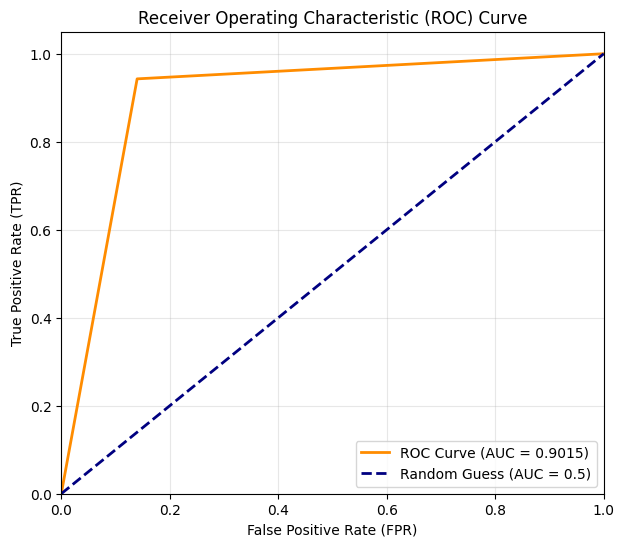

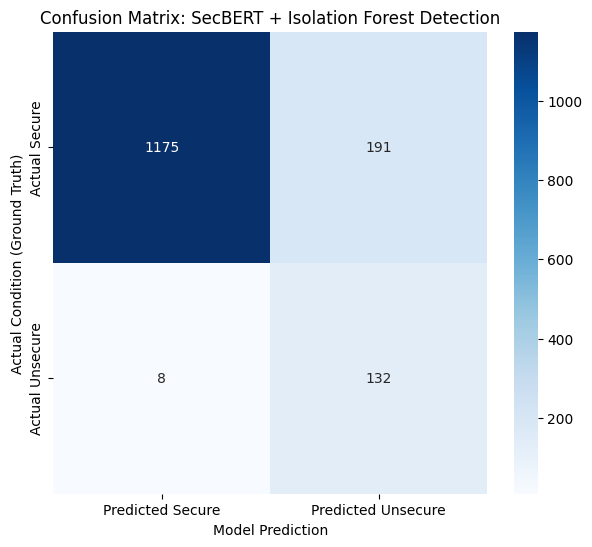

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder

# --- PART 8: FULL EVALUATION (REPORT + AUC + ROC PLOT + HEATMAP) ---

def evaluate_model(df):
    # 1. Define Ground Truth (Actual Labels) Automatically for Validation
    #    We classify data as "Unsecure" if it contains attack keywords OR has high risk scores.
    def get_ground_truth(row):
        text = str(row['clean_text']).upper()
        keywords = ["UNION", "SELECT", "OR 1=1", "SCRIPT", "DROP", "ALERT", "XSS", "../", "ADMIN'"]

        # Logic: If dangerous keywords are present OR Risk Score > 3, it's an ATTACK.
        is_attack = any(k in text for k in keywords) or (row['risk_char_count'] > 3)
        return "Unsecure" if is_attack else "Secure"

    # Apply function to the entire testing dataset
    true_labels = df.apply(get_ground_truth, axis=1).tolist()

    # 2. Display Classification Report (Text-based)
    print("\n" + "="*60)
    print(f"📊 QUANTITATIVE EVALUATION RESULTS (TESTING DATA)")
    print("="*60)
    print(classification_report(true_labels, df['prediction'], digits=4))

    # 3. Calculate & Visualize ROC-AUC Score
    try:
        le = LabelEncoder()
        # Encode: Secure=0, Unsecure=1
        y_true = le.fit_transform(true_labels)
        # Ensure 'Unsecure' is mapped to 1 for AUC calculation
        y_pred = [1 if x == "Unsecure" else 0 for x in df['prediction']]

        # Calculate AUC Score
        auc_score = roc_auc_score(y_true, y_pred)
        print("-" * 30)
        print(f"🚀 ROC-AUC Score: {auc_score:.4f}")
        print("-" * 30)
        print("(Values closer to 1.0 indicate excellent differentiation between attacks)")

        # --- NEW: PLOT ROC CURVE ---
        # Calculate False Positive Rate (FPR) and True Positive Rate (TPR)
        fpr, tpr, thresholds = roc_curve(y_true, y_pred)

        plt.figure(figsize=(7, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.5)')

        # Formatting the plot
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate (FPR)')
        plt.ylabel('True Positive Rate (TPR)')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)

        # Show the ROC plot
        plt.show()

    except Exception as e:
        print(f"⚠️ Failed to calculate/plot AUC: {e}")

    # 4. Visualize Confusion Matrix (Heatmap)
    #    Essential for Chapter 4 Results & Discussion
    cm = confusion_matrix(true_labels, df['prediction'], labels=["Secure", "Unsecure"])

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Secure', 'Predicted Unsecure'],
                yticklabels=['Actual Secure', 'Actual Unsecure'])

    plt.title('Confusion Matrix: SecBERT + Isolation Forest Detection')
    plt.ylabel('Actual Condition (Ground Truth)')
    plt.xlabel('Model Prediction')

    # Show the Confusion Matrix plot
    plt.show()

# Run Evaluation Function
evaluate_model(test_df_processed)

##BAGIAN 7: Analisis Kualitatif

In [ ]:
import pandas as pd

# --- PART 7: QUALITATIVE ANALYSIS (MODIFIED FOR CSV EXPORT) ---

def analyze_results_and_export_csv(df, output_filename="network_security_analysis.csv"):
    print("\n🔍 ANALYZING AND EXPORTING DATA TO CSV...")

    # List to hold the rows of data to be exported
    export_data = []

    # ---------------------------------------------------------
    # 1. PROCESS UNSECURE DATA (ATTACKS)
    # ---------------------------------------------------------
    attacks = df[df['prediction'] == 'Unsecure'].head(50)

    if attacks.empty:
        print("✅ No attacks detected.")
    else:
        for i, row in attacks.iterrows():
            # Retrieve score values
            risk_score = row.get('risk_char_count', 0)
            ip_freq_val = row.get('ip_freq_log', 0)
            entropy_val = row.get('entropy', 0)
            port_r = row.get('port_risk', row.get('port_behavior_risk', 0))
            foreign_r = row.get('foreign_risk', row.get('foreign_context_risk', 0))

            # Determine danger indicators/reasons
            reasons = []
            if risk_score > 2:
                reasons.append(f"Dangerous Payload ({risk_score})")
            if ip_freq_val > 1.5:
                reasons.append(f"Brute Force/Spam ({ip_freq_val:.2f})")
            if port_r > 0:
                reasons.append("Unusual Port")
            if foreign_r > 0:
                reasons.append("Foreign Risk")

            # If no manual reasons are found, the anomaly was detected semantically by SecBERT
            if not reasons:
                reasons.append("Semantic Anomaly (SecBERT)")

            # Append to the export list
            export_data.append({
                'Status': 'Unsecure',
                'Source IP': row.get('SOURCE IP', 'N/A'),
                'Dest Port': row.get('DEST PORT', 'N/A'),
                'Country': row.get('SOURCE_COUNTRY', '-'),
                'Raw Payload': row.get('DATA (PLAINTEXT)', ''),
                'Decoded Payload': row.get('clean_text', ''),
                'Risk Char Score': risk_score,
                'IP Freq Log': round(ip_freq_val, 2),
                'Entropy': round(entropy_val, 2),
                'Danger Indicators': " | ".join(reasons)
            })

    # ---------------------------------------------------------
    # 2. PROCESS SECURE DATA (NORMAL)
    # ---------------------------------------------------------
    secure = df[df['prediction'] == 'Secure'].head(50)

    if not secure.empty:
        for i, row in secure.iterrows():
            export_data.append({
                'Status': 'Secure',
                'Source IP': row.get('SOURCE IP', 'N/A'),
                'Dest Port': row.get('DEST PORT', 'N/A'),
                'Country': row.get('SOURCE_COUNTRY', '-'),
                'Raw Payload': row.get('DATA (PLAINTEXT)', ''),
                'Decoded Payload': row.get('clean_text', ''),
                'Risk Char Score': row.get('risk_char_count', 0),
                'IP Freq Log': round(row.get('ip_freq_log', 0), 2),
                'Entropy': round(row.get('entropy', 0), 2),
                'Danger Indicators': "None"
            })

    # ---------------------------------------------------------
    # 3. EXPORT TO CSV
    # ---------------------------------------------------------
    if export_data:
        # Convert the list of dictionaries into a DataFrame
        result_df = pd.DataFrame(export_data)

        try:
            # Export to CSV without including the index column
            result_df.to_csv(output_filename, index=False, encoding='utf-8')
            print(f"✅ Success! Analysis results have been exported to: {output_filename}")
        except Exception as e:
            print(f"❌ Failed to export the file: {e}")
    else:
        print("⚠️ No data available to export.")

# Execute the function
analyze_results_and_export_csv(test_df_processed, output_filename="Traffic_Analysis_Report.csv")


🔍 ANALYZING AND EXPORTING DATA TO CSV...
✅ Success! Analysis results have been exported to: Traffic_Analysis_Report.csv


##BAGIAN 8: Visualisasi Tambahan

📊 Generating Additional Visualizations for Chapter 4...


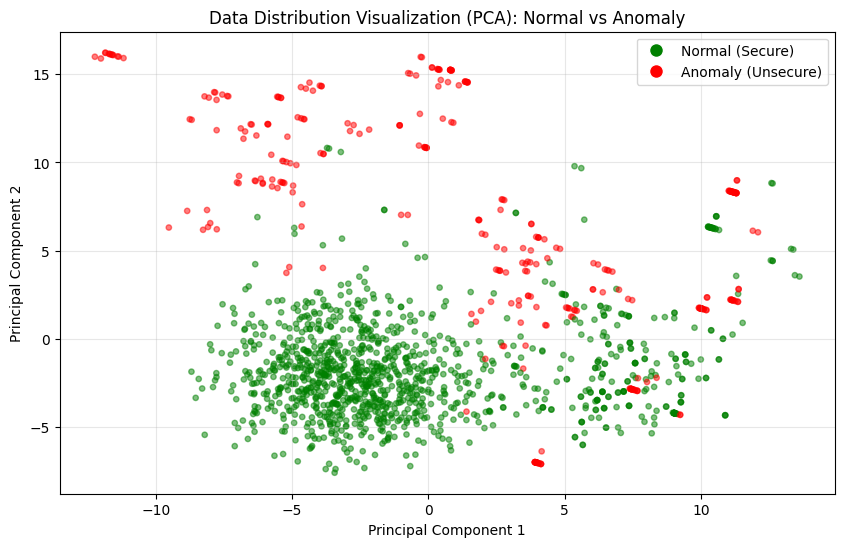

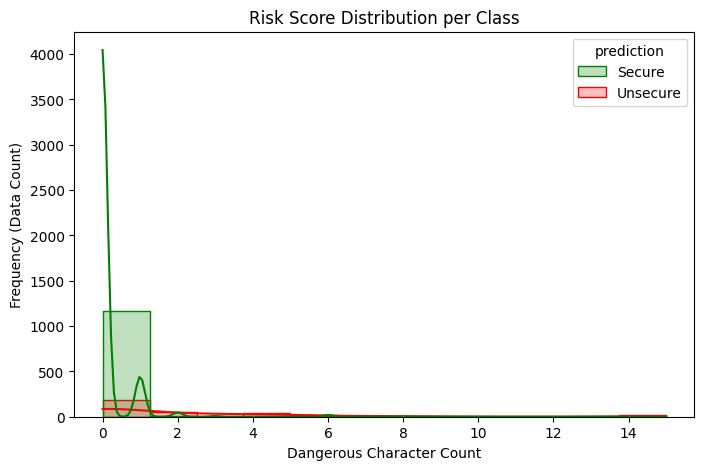

✅ All Visualizations Completed.


In [ ]:
# --- PART 8: ADDITIONAL VISUALIZATION (SCATTER PLOT & RISK DISTRIBUTION) ---
print("📊 Generating Additional Visualizations for Chapter 4...")

# 1. PCA Scatter Plot Visualization (Chapter 4.2.4)
# We reduce the Hybrid features to 2 Dimensions for plotting purposes
viz_pca = PCA(n_components=2)
hybrid_test_2d = viz_pca.fit_transform(hybrid_test)

plt.figure(figsize=(10, 6))
# Define colors: Red for anomalies, Green for normal traffic
colors = ['red' if x == 'Unsecure' else 'green' for x in test_df_processed['prediction']]
plt.scatter(hybrid_test_2d[:, 0], hybrid_test_2d[:, 1], c=colors, alpha=0.5, s=15)

# Create manual legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', label='Normal (Secure)', markersize=10),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Anomaly (Unsecure)', markersize=10)
]
plt.legend(handles=legend_elements)
plt.title('Data Distribution Visualization (PCA): Normal vs Anomaly')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Risk Score Distribution Visualization (Chapter 4.2.3)
plt.figure(figsize=(8, 5))
sns.histplot(
    data=test_df_processed,
    x='risk_char_count',
    hue='prediction',
    kde=True,
    palette={'Secure': 'green', 'Unsecure': 'red'},
    element="step"
)
plt.title('Risk Score Distribution per Class')
plt.xlabel('Dangerous Character Count')
plt.ylabel('Frequency (Data Count)')
plt.show()

print("✅ All Visualizations Completed.")